# Assignment -- Train and Evaluate Your Sketch VAE

This assignment brings together everything from this week. You will train the VAE on a category of your choice, evaluate its reconstructions, and experiment with the latent space.

**What you need to submit:**
- A fully trained VAE (20+ epochs) on a category other than cat
- Loss curves for total loss, reconstruction loss, and KL loss
- A 4-column grid showing original vs reconstructed sketches
- Latent space interpolation between two sketches
- Answers to the reflection questions

**Target:** reconstructions should be recognisable as the correct category.

## Step 1 -- Load your category

Use the same category you chose in the data engineering assignment. If you did not complete that assignment yet, pick any category from the list in that notebook.

In [2]:
import torch, torch.nn as nn, torch.nn.functional as F
import numpy as np, json, os
import matplotlib.pyplot as plt
import urllib.request
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence, pack_padded_sequence

# ---- data pipeline ----
def drawing_to_stroke3(drawing):
    strokes = []
    for stroke in drawing:
        xs, ys = stroke[0], stroke[1]
        for i in range(len(xs)):
            dx = xs[i] - xs[i-1] if i > 0 else 0
            dy = ys[i] - ys[i-1] if i > 0 else 0
            pen_lifted = 1 if i == len(xs) - 1 else 0
            strokes.append([dx, dy, pen_lifted])
    return np.array(strokes, dtype=np.float32)

def normalise_stroke3(stroke3):
    s = stroke3.copy()
    coords = s[:, :2]
    s[:, :2] = (coords - coords.mean(axis=0)) / (coords.std(axis=0) + 1e-8)
    return s

class QuickDrawDataset(Dataset):
    def __init__(self, path, max_len=200, max_samples=5000):
        self.samples = []
        with open(path) as f:
            for i, line in enumerate(f):
                if i >= max_samples: break
                d  = json.loads(line)
                s3 = drawing_to_stroke3(d['drawing'])
                s3 = normalise_stroke3(s3)
                if len(s3) > max_len: s3 = s3[:max_len]
                self.samples.append(torch.tensor(s3, dtype=torch.float32))
    def __len__(self): return len(self.samples)
    def __getitem__(self, idx): return self.samples[idx]

def collate_fn(batch):
    lengths = [seq.shape[0] for seq in batch]
    padded  = pad_sequence(batch, batch_first=True, padding_value=0.0)
    return padded, lengths

# ---- encoder ----
class Encoder(nn.Module):
    def __init__(self, input_dim=3, hidden_dim=256, latent_dim=128):
        super().__init__()
        self.lstm      = nn.LSTM(input_dim, hidden_dim, batch_first=True, bidirectional=True)
        self.fc_mu     = nn.Linear(hidden_dim * 2, latent_dim)
        self.fc_logvar = nn.Linear(hidden_dim * 2, latent_dim)
    def forward(self, x, lengths):
        packed = pack_padded_sequence(x, lengths, batch_first=True, enforce_sorted=False)
        _, (h, _) = self.lstm(packed)
        h = torch.cat([h[0], h[1]], dim=-1)
        return self.fc_mu(h), self.fc_logvar(h)

def reparameterise(mu, logvar):
    std = torch.exp(0.5 * logvar)
    return mu + torch.randn_like(std) * std

def kl_loss(mu, logvar):
    return -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp())

# ---- data ----
os.makedirs('data', exist_ok=True)
path = 'data/dog.ndjson'
if not os.path.exists(path):
    urllib.request.urlretrieve(
        'https://storage.googleapis.com/quickdraw_dataset/full/simplified/dog.ndjson', path)

dataset = QuickDrawDataset(path, max_len=200, max_samples=3000)
loader  = DataLoader(dataset, batch_size=32, shuffle=True, collate_fn=collate_fn)
print(f'Dataset: {len(dataset)} samples')
print('Setup complete.')




Dataset: 3000 samples
Setup complete.


## Step 2 -- Define and train the VAE

Copy the Encoder, Decoder, SketchVAE, reparameterise, kl_loss, and vae_loss from the VAE notebook. Then train for at least 20 epochs.

In [3]:
# TODO: Paste all model definitions here
class Decoder(nn.Module):
    def __init__(self, latent_dim=128, hidden_dim=512, output_dim=3):
        '''
        latent_dim : size of z
        hidden_dim : size of the decoder LSTM hidden state
        output_dim : 3 for stroke-3 (dx, dy, pen_lifted)
        '''
        super().__init__()
        # Project z into the initial hidden and cell states of the LSTM
        self.fc_hidden = nn.Linear(latent_dim, hidden_dim)
        self.fc_cell   = nn.Linear(latent_dim, hidden_dim)

        self.lstm = nn.LSTM(
            input_size=output_dim,
            hidden_size=hidden_dim,
            batch_first=True
        )
        self.fc_out = nn.Linear(hidden_dim, output_dim)

    def forward(self, z, target_seq):
        '''
        Teacher-forced forward pass (used during training).

        z          : latent vector, shape (batch, latent_dim)
        target_seq : ground truth sequence, shape (batch, seq_len, 3)
                     we shift it right by one step to use as decoder input

        Returns:
            output : predicted sequence, shape (batch, seq_len, 3)
        '''
        batch_size = z.shape[0]

        # Initialise hidden state from z
        h0 = torch.tanh(self.fc_hidden(z)).unsqueeze(0)   # (1, batch, hidden)
        c0 = torch.tanh(self.fc_cell(z)).unsqueeze(0)

        # Shift target right: prepend a zero start token, drop the last step
        start_token = torch.zeros(batch_size, 1, 3, device=z.device)
        decoder_input = torch.cat([start_token, target_seq[:, :-1, :]], dim=1)

        output, _ = self.lstm(decoder_input, (h0, c0))
        output = self.fc_out(output)   # (batch, seq_len, 3)
        return output

    def generate(self, z, max_len=200):
        '''
        Autoregressive generation (used during inference).
        Feed each predicted step back as the next input.
        '''
        batch_size = z.shape[0]
        h = torch.tanh(self.fc_hidden(z)).unsqueeze(0)
        c = torch.tanh(self.fc_cell(z)).unsqueeze(0)

        input_step = torch.zeros(batch_size, 1, 3, device=z.device)
        outputs = []

        for _ in range(max_len):
            out, (h, c) = self.lstm(input_step, (h, c))
            step = self.fc_out(out)           # (batch, 1, 3)
            outputs.append(step)
            input_step = step                 # feed prediction back

        return torch.cat(outputs, dim=1)      # (batch, max_len, 3)

decoder = Decoder(latent_dim=128, hidden_dim=512)
print(decoder)



Decoder(
  (fc_hidden): Linear(in_features=128, out_features=512, bias=True)
  (fc_cell): Linear(in_features=128, out_features=512, bias=True)
  (lstm): LSTM(3, 512, batch_first=True)
  (fc_out): Linear(in_features=512, out_features=3, bias=True)
)


In [4]:
#full vae
class SketchVAE(nn.Module):
    def __init__(self, input_dim=3, hidden_dim=256, latent_dim=128, decoder_hidden=512):
        super().__init__()
        self.encoder = Encoder(input_dim, hidden_dim, latent_dim)
        self.decoder = Decoder(latent_dim, decoder_hidden, input_dim)

    def forward(self, x, lengths):
        mu, logvar = self.encoder(x, lengths)
        z          = reparameterise(mu, logvar)
        recon      = self.decoder(z, x)
        return recon, mu, logvar

model = SketchVAE()
total = sum(p.numel() for p in model.parameters())
print(f'Total parameters: {total:,}')

# Quick forward pass test
padded, lengths = next(iter(loader))
recon, mu, logvar = model(padded, lengths)
print('Input shape      :', padded.shape)
print('Reconstruction   :', recon.shape)
print('mu shape         :', mu.shape)

Total parameters: 1,858,307
Input shape      : torch.Size([32, 109, 3])
Reconstruction   : torch.Size([32, 109, 3])
mu shape         : torch.Size([32, 128])


In [5]:
# vae loss
def vae_loss(recon, target, mu, logvar, kl_weight=0.5):
    '''
    recon    : predicted sequence (batch, seq_len, 3)
    target   : ground truth sequence (batch, seq_len, 3)
    mu       : latent mean
    logvar   : latent log-variance
    kl_weight: weight on the KL term
    '''
    # MSE on position deltas
    recon_pos  = F.mse_loss(recon[:, :, :2], target[:, :, :2])

    # BCE on pen state
    pen_pred   = torch.sigmoid(recon[:, :, 2])
    recon_pen  = F.binary_cross_entropy(pen_pred, target[:, :, 2], reduction='mean')

    kl         = kl_loss(mu, logvar)

    total      = recon_pos + recon_pen + kl_weight * kl
    return total, recon_pos, recon_pen, kl

# Test loss
loss, rp, rpen, kl = vae_loss(recon, padded, mu, logvar)
print(f'Total loss  : {loss.item():.4f}')
print(f'Recon pos   : {rp.item():.4f}')
print(f'Recon pen   : {rpen.item():.4f}')
print(f'KL loss     : {kl.item():.4f}')


Total loss  : 1.2717
Recon pos   : 0.5725
Recon pen   : 0.6989
KL loss     : 0.0007


In [6]:
# TODO: Training loop -- at least 20 epochs, with KL annealing
# Store total loss, recon_pos loss, and kl loss per epoch
device    = 'cuda' if torch.cuda.is_available() else 'cpu'
model     = SketchVAE().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

num_epochs = 20
history    = {'total': [], 'recon_pos': [], 'recon_pen': [], 'kl': []}

for epoch in range(num_epochs):
    model.train()
    epoch_losses = {'total': 0, 'recon_pos': 0, 'recon_pen': 0, 'kl': 0}

    # KL annealing: start at 0, linearly increase to 0.5 over training
    kl_weight = min(0.5, epoch / num_epochs)

    for padded, lengths in loader:
        padded = padded.to(device)

        recon, mu, logvar = model(padded, lengths)
        loss, rp, rpen, kl = vae_loss(recon, padded, mu, logvar, kl_weight)

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)  # gradient clipping
        optimizer.step()

        epoch_losses['total']     += loss.item()
        epoch_losses['recon_pos'] += rp.item()
        epoch_losses['recon_pen'] += rpen.item()
        epoch_losses['kl']        += kl.item()

    n = len(loader)
    for k in history:
        history[k].append(epoch_losses[k] / n)

    print(f'Epoch {epoch+1:02d}/{num_epochs} | '
          f'loss {history["total"][-1]:.4f} | '
          f'recon_pos {history["recon_pos"][-1]:.4f} | '
          f'kl {history["kl"][-1]:.4f} | '
          f'kl_weight {kl_weight:.2f}')



Epoch 01/20 | loss 0.7252 | recon_pos 0.4585 | kl 6.7279 | kl_weight 0.00
Epoch 02/20 | loss 0.6227 | recon_pos 0.3942 | kl 0.1096 | kl_weight 0.05
Epoch 03/20 | loss 0.5799 | recon_pos 0.3762 | kl 0.0467 | kl_weight 0.10
Epoch 04/20 | loss 0.5494 | recon_pos 0.3566 | kl 0.0347 | kl_weight 0.15
Epoch 05/20 | loss 0.5267 | recon_pos 0.3423 | kl 0.0284 | kl_weight 0.20
Epoch 06/20 | loss 0.5084 | recon_pos 0.3295 | kl 0.0238 | kl_weight 0.25
Epoch 07/20 | loss 0.4874 | recon_pos 0.3154 | kl 0.0203 | kl_weight 0.30
Epoch 08/20 | loss 0.4776 | recon_pos 0.3083 | kl 0.0173 | kl_weight 0.35
Epoch 09/20 | loss 0.4630 | recon_pos 0.2988 | kl 0.0149 | kl_weight 0.40
Epoch 10/20 | loss 0.4580 | recon_pos 0.2954 | kl 0.0133 | kl_weight 0.45
Epoch 11/20 | loss 0.4500 | recon_pos 0.2905 | kl 0.0116 | kl_weight 0.50
Epoch 12/20 | loss 0.4471 | recon_pos 0.2885 | kl 0.0114 | kl_weight 0.50
Epoch 13/20 | loss 0.4466 | recon_pos 0.2878 | kl 0.0111 | kl_weight 0.50
Epoch 14/20 | loss 0.4412 | recon_pos 

## Step 3 -- Plot loss curves

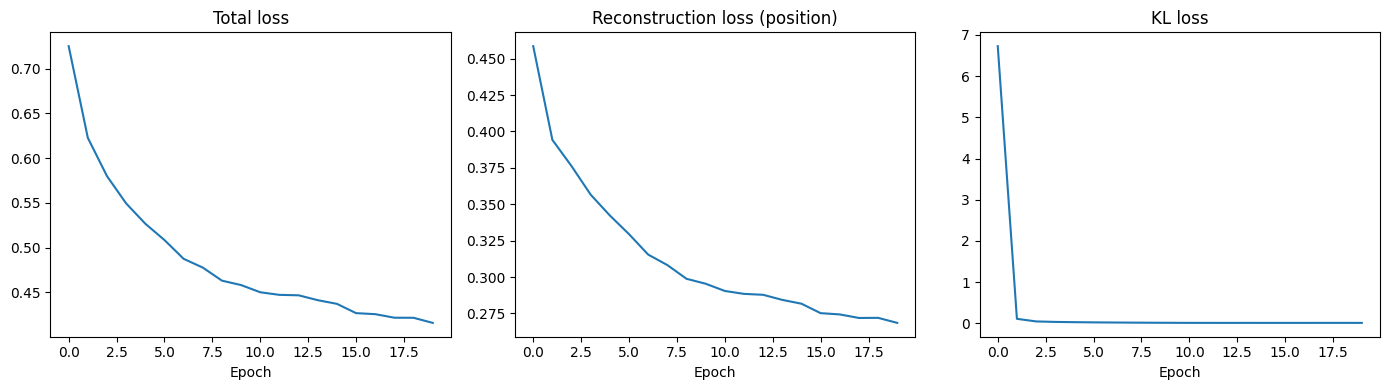

In [7]:
# TODO: Plot total loss, reconstruction loss, and KL loss on a single figure with 3 subplots
# YOUR CODE HERE
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
axes[0].plot(history['total']);     axes[0].set_title('Total loss')
axes[1].plot(history['recon_pos']); axes[1].set_title('Reconstruction loss (position)')
axes[2].plot(history['kl']);        axes[2].set_title('KL loss')
for ax in axes:
    ax.set_xlabel('Epoch')
plt.tight_layout()
plt.show()

## Step 4 -- Visualise reconstructions

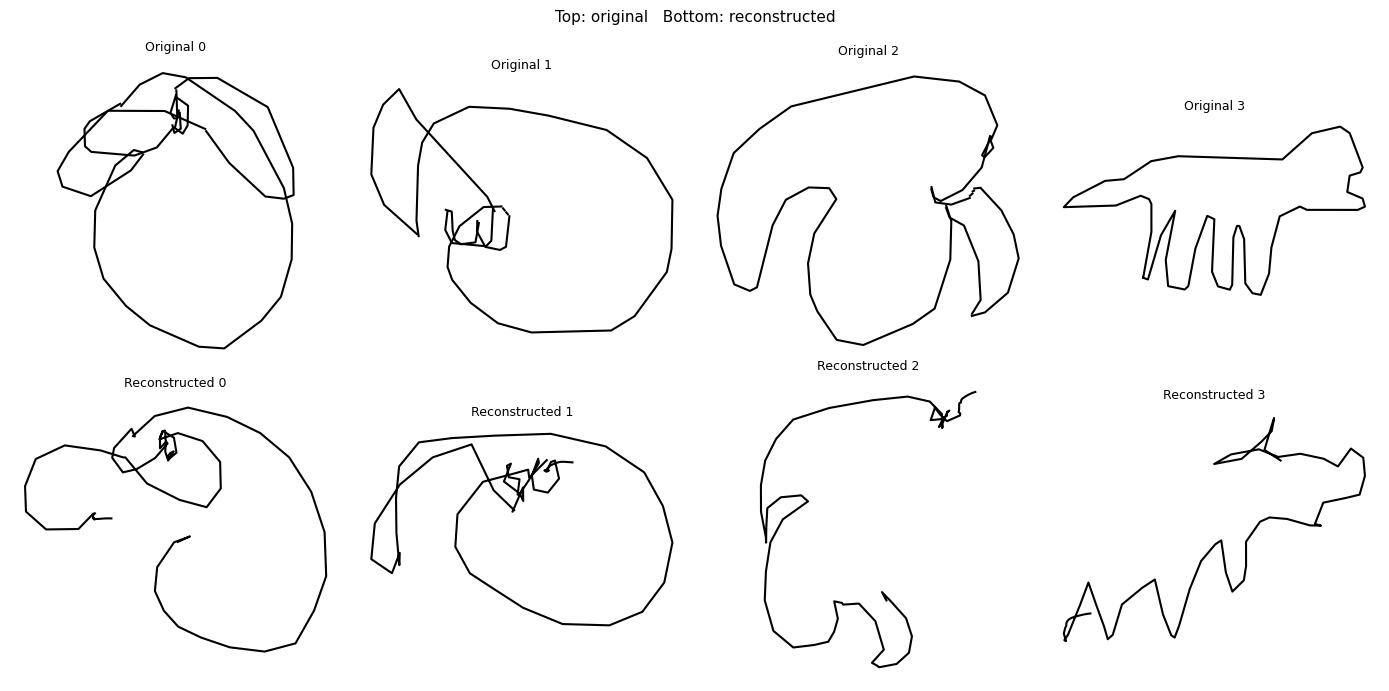

In [10]:
# TODO: Plot a 2x4 grid: top row = 4 original sketches, bottom row = their reconstructions
def stroke3_to_absolute(stroke3):
    abs_coords = np.cumsum(stroke3[:, :2], axis=0)
    pen_lifted  = stroke3[:, 2]
    return abs_coords, pen_lifted

def plot_sketch(stroke3_np, title='', ax=None):
    coords, pen_lifted = stroke3_to_absolute(stroke3_np)
    if ax is None:
        fig, ax = plt.subplots(figsize=(3, 3))
    ax.set_aspect('equal'); ax.invert_yaxis(); ax.axis('off'); ax.set_title(title, fontsize=9)
    start = 0
    for i in range(len(pen_lifted)):
        if pen_lifted[i] > 0.5:
            seg = coords[start : i + 1]
            ax.plot(seg[:, 0], seg[:, 1], 'k-', linewidth=1.5)
            start = i + 1
    # Draw the last segment if it wasn't drawn
    if start < len(coords):
        seg = coords[start:]
        ax.plot(seg[:, 0], seg[:, 1], 'k-', linewidth=1.5)

model.eval()
with torch.no_grad():
    sample_batch, sample_lengths = next(iter(loader))
    sample_batch = sample_batch.to(device)
    recon, mu, logvar = model(sample_batch, sample_lengths)

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
for i in range(4):
    original = sample_batch[i].cpu().numpy()
    reconstructed = recon[i].cpu().numpy()
    plot_sketch(original,      title=f'Original {i}',       ax=axes[0, i])
    plot_sketch(reconstructed, title=f'Reconstructed {i}',  ax=axes[1, i])

plt.suptitle('Top: original   Bottom: reconstructed', fontsize=11)
plt.tight_layout()
plt.show()



## Step 5 -- Latent interpolation

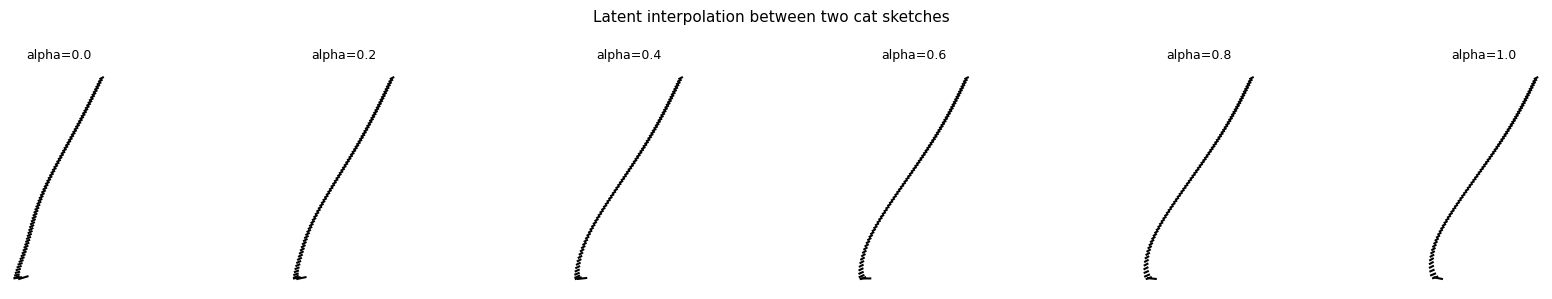

In [9]:
# TODO: Pick any two sketches from your dataset.
#       Encode them to get mu1 and mu2.
#       Interpolate between mu1 and mu2 in 6 steps.
#       Generate and plot the 6 interpolated sketches in a single row.
model.eval()
with torch.no_grad():
    # Encode two sketches
    s1 = dataset[0].unsqueeze(0).to(device)
    s2 = dataset[1].unsqueeze(0).to(device)
    mu1, _ = model.encoder(s1, [s1.shape[1]])
    mu2, _ = model.encoder(s2, [s2.shape[1]])

    # Interpolate between mu1 and mu2 in 6 steps
    steps = 6
    alphas = torch.linspace(0, 1, steps)
    z_interp = torch.stack([alpha * mu2 + (1 - alpha) * mu1 for alpha in alphas]).squeeze(1)

    generated = model.decoder.generate(z_interp, max_len=150)

fig, axes = plt.subplots(1, steps, figsize=(3 * steps, 3))
for i, ax in enumerate(axes):
    plot_sketch(generated[i].cpu().numpy(),
                title=f'alpha={alphas[i]:.1f}', ax=ax)

plt.suptitle('Latent interpolation between two cat sketches', fontsize=11)
plt.tight_layout()
plt.show()


## Step 6 -- Reflection questions

In [13]:
# Q1: What does the KL loss being very small early in training tell you?
#-->> it tells that at the start the model tries to keep the sketches at distinct points in the latent space bu gradually it starts to train and concentrate them.
#     Why does KL annealing help?
# kl annealing helps because of gradual increase of the beta from 0 to 0.5 
#the model learns to minimize recontruction loss by gradually balancing the kl div and learn to draw.

# Q2: Look at your reconstructions. Which parts of the sketch does the model

#     get right first? Which parts are hardest to reconstruct? Why might that be?
#-->> the model gets the starting strokes / overall shape of the sketch correct but faces difficulty to predict the sharp turn strokes .
# this might be due to MSE loss penalty to sharp turns and the difficulty to remember the full drawing .

# Q3: Does your latent interpolation look smooth? What does smoothness
#     in the latent space mean for the model's understanding of sketches?
#-->>it does look smooth in the sense of overall drawing , but it is very noisy/stroke heavy line, it is due to keeping very less MSE loss.

# Q4: The decoder generates strokes autoregressively -- one step at a time.
#     What are the risks of this approach over long sequences?

# ans4-->> the risk related to this approach is that while generating the drawings , the stroke experiences slight error compared to the 
#actual ground drawing and over time as the model predicts next stroke on previous stroke the error compounds and makes a wrong sketch.

## Bonus (optional)
- Try training on two categories mixed together. Does the model separate them in latent space?
- Visualise 100 latent vectors using PCA or t-SNE (use `sklearn.decomposition.PCA`)
- Experiment with different latent_dim values (32, 64, 256). How does it affect reconstruction quality?

## Submission checklist

- [ ] VAE trained for 20+ epochs on a non-cat category
- [ ] Loss curves (total, recon, KL) plotted
- [ ] 2x4 reconstruction grid
- [ ] Latent interpolation (6 steps) plotted
- [ ] All 4 reflection questions answered